In [1]:
import os
print(os.listdir())

['BSANStat_cleaned_fixed.ipynb', 'All Matches.csv', 'BSANStat Models.ipynb', 'BSANStat Models New.ipynb', 'README.md', 'All NCAA Player Rankings.csv', 'BSANStat.ipynb', '.git', 'All NFL Scouting Combine Results.csv']


In [2]:
# Run this once if packages are missing
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df1 = pd.read_csv("All Matches.csv", encoding="latin1")
df2 = pd.read_csv("All NCAA Player Rankings.csv", encoding="latin1")
df3 = pd.read_csv("All NFL Scouting Combine Results.csv", encoding="latin1")

In [4]:
df1.head()

,Season,Name,Position,Team,Conference,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
0,2025,Haynes King,QB,Georgia Tech,ACC,0.321,0.354,0.323,0.160,0.308,...,31.875,86.54,4.46,33.50,11,116.00,6.89,4.17,300,1
1,2025,Joe Fagnano,QB,UConn,Ind,0.476,0.476,0.474,0.237,0.531,...,31.375,80.14,4.83,35.00,17,118.00,6.17,4.35,300,1
2,2025,Caullin Lacy,WR,Louisville,ACC,0.163,0.232,-0.196,-0.141,0.429,...,29.375,70.67,4.55,33.50,29,116.00,6.35,4.56,300,1
3,2025,Carson Beck,QB,Miami,ACC,0.306,0.351,0.048,0.148,0.273,...,30.625,75.00,4.55,68.29,14,147.56,9.47,6.22,65,1
4,2025,Taylen Green,QB,Arkansas,SEC,0.415,0.344,0.680,0.167,0.524,...,34.750,79.41,4.36,43.50,18,134.00,6.10,5.42,182,1


In [5]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

(326, 36)
(12409, 23)
(1277, 18)


In [6]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['Season', 'Name', 'Position', 'Team', 'Conference', 'AveragePPA All',
       'AveragePPA Pass', 'AveragePPA Rush', 'AveragePPA FirstDown',
       'AveragePPA SecondDown', 'AveragePPA ThirdDown',
       'AveragePPA StandardDowns', 'AveragePPA PassingDowns', 'TotalPPA All',
       'TotalPPA Pass', 'TotalPPA Rush', 'TotalPPA FirstDown',
       'TotalPPA SecondDown', 'TotalPPA ThirdDown', 'TotalPPA StandardDowns',
       'TotalPPA PassingDowns', 'index_combine', 'Season_combine',
       'Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Arm (inches)',
       'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)',
       'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)',
       'Shuttle (seconds)', 'Overall Pick', 'Combine Participation'],
      dtype='str')
Index(['Season', 'Name', 'Position', 'Team', 'Conference', 'AveragePPA All',
       'AveragePPA Pass', 'AveragePPA Rush', 'AveragePPA FirstDown',
       'AveragePPA SecondDown', 'AveragePPA ThirdDown',
      

## Descriptive Statistics
This summarizes the numeric variables in the matched dataset, including count, mean, standard deviation, min, max, and median.


In [7]:
summary_stats = df1.describe().T
summary_stats["median"] = df1.median(numeric_only=True)

summary_stats

,count,mean,std,min,25%,50%,75%,max,median
Season,326.0,2024.046012,0.804430,2023.000,2023.00000,2024.0000,2025.00000,2025.000,2024.0000
AveragePPA All,326.0,0.593871,0.398821,-1.108,0.30375,0.5360,0.87275,2.411,0.5360
AveragePPA Pass,326.0,0.663187,0.403747,-1.108,0.40125,0.6280,0.92525,2.411,0.6280
AveragePPA Rush,326.0,0.203187,0.745030,-3.628,-0.07175,0.2205,0.47725,3.519,0.2205
AveragePPA FirstDown,326.0,0.416558,0.381328,-1.108,0.14625,0.3440,0.63325,2.097,0.3440
AveragePPA SecondDown,326.0,0.576368,0.457011,-0.697,0.25625,0.5210,0.88600,2.411,0.5210
AveragePPA ThirdDown,326.0,0.957939,0.586473,-1.500,0.59925,0.8650,1.32500,2.753,0.8650
AveragePPA StandardDowns,326.0,0.489356,0.365180,-1.108,0.23675,0.4340,0.73100,1.755,0.4340
AveragePPA PassingDowns,326.0,0.796322,0.552773,-1.267,0.40775,0.7175,1.14425,2.624,0.7175
TotalPPA All,326.0,61.732258,53.521327,-7.402,26.56750,48.5890,75.85425,300.687,48.5890


Combine Participation = 0.791
About 79% of players attended the combine. This likely means the dataset is biased toward higher-level NFL prospects.

Overall Pick has a max and 75th percentile of 300
Many players were undrafted (coded as 300). This likely made exact-pick prediction harder and hurt the OLS model fit.

Very large max values for Wingspan, Vertical, and Broad Jump
These are likely outliers or formatting/conversion errors that could skew regression results.

AveragePPA ThirdDown is much higher than First or Second Down
Third-down success is more valuable because it extends drives and prevents punts.

AveragePPA Rush has a much larger standard deviation than AveragePPA Pass
Rushing performance likely varies more by player role and offensive scheme.

Median 40-yard dash is 4.51 seconds
This suggests most players in the dataset are legitimate high-level athletes with similar NFL-caliber speed.

Overall Pick standard deviation is very high (102)
Draft position is extremely unpredictable because many factors beyond stats affect NFL draft decisions.

Many PPA variables probably have multicollinearity
Metrics like AveragePPA All, PassingDowns, and ThirdDown measure similar performance concepts, so they are likely strongly correlated.

## Create Draft Status Variable
This creates a new Drafted column that labels players as Drafted or Undrafted based on Overall Pick.


In [8]:
df1["Drafted"] = df1["Overall Pick"].apply(lambda x: "Drafted" if x != 300 else "Undrafted")

## Compare Mean Values by Draft Status
This compares the average numeric values for drafted and undrafted players.


In [9]:
df1.groupby("Drafted").mean(numeric_only=True)

,Season,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,AveragePPA ThirdDown,AveragePPA StandardDowns,AveragePPA PassingDowns,TotalPPA All,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
Drafted,,,,,,,,,,,,,,,,,,,,,
Drafted,2024.00000,0.616717,0.684165,0.236861,0.432378,0.588330,0.98650,0.512661,0.816809,65.848904,...,31.33750,76.633609,4.633826,36.489304,20.873913,123.190739,7.065478,4.430565,123.934783,0.786957
Undrafted,2024.15625,0.539135,0.612927,0.122510,0.378656,0.547708,0.88951,0.433521,0.747240,51.869458,...,31.36849,76.613646,4.592500,35.909167,20.562500,121.961562,7.111563,4.351042,300.000000,0.802083


Drafted players have higher PPA metrics across almost every category --> Better on-field performance likely improves draft chances.
The biggest gaps are in AveragePPA Rush and TotalPPA All --> Explosive/high-volume production may matter a lot to NFL scouts.

Drafted players performed better on third downs --> NFL teams likely value players who succeed in high-pressure situations.

Drafted players had faster average 40-yard dash times (4.59 vs 4.63) --> Speed appears to matter, even if the difference is small.

Drafted players had slightly better agility scores (3-Cone and Shuttle) --> Quickness/change of direction may separate borderline prospects.

Physical measurements are almost identical between groups --> Height, arm length, and wingspan alone likely do not determine draft status.

Bench press numbers are very similar --> Pure strength may matter less than athleticism and production.

Combine participation is nearly the same between groups --> Simply attending the combine does not guarantee being drafted.

## Compare Median Values by Draft Status
This compares the middle value of each numeric variable for drafted and undrafted players.


In [10]:
df1.groupby("Drafted").median(numeric_only=True)

,Season,AveragePPA All,AveragePPA Pass,AveragePPA Rush,AveragePPA FirstDown,AveragePPA SecondDown,AveragePPA ThirdDown,AveragePPA StandardDowns,AveragePPA PassingDowns,TotalPPA All,...,Arm (inches),Wingspan (inches),40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Overall Pick,Combine Participation
Drafted,,,,,,,,,,,,,,,,,,,,,
Drafted,2024.0,0.563,0.6425,0.2405,0.360,0.5265,0.891,0.4525,0.7525,51.5255,...,31.375,76.5000,4.48,36.00,21.0,122.95,6.975,4.30,122.5,1.0
Undrafted,2024.0,0.480,0.5705,0.1955,0.285,0.4495,0.834,0.3635,0.6280,36.6415,...,31.500,76.6875,4.57,35.25,19.5,122.00,7.005,4.31,300.0,1.0


Median differences are smaller than mean differences, suggesting a few elite drafted players inflated the averages.

Speed stands out more in the median comparison (4.48 vs 4.57), meaning faster players were more consistently drafted.

Physical measurements are still very similar, suggesting size alone did not separate drafted and undrafted players much.

Drafted players still had better PPA metrics across the board, reinforcing that production mattered.

## Compare Quartiles by Draft Status
This shows the 25th, 50th, and 75th percentiles for drafted and undrafted players.


In [11]:
df1.groupby("Drafted").quantile([0.25, 0.50, 0.75], numeric_only=True)

Season  AveragePPA All  AveragePPA Pass  AveragePPA Rush  \
Drafted                                                                    
Drafted   0.25  2023.0         0.31925          0.42200         -0.04975   
          0.50  2024.0         0.56300          0.64250          0.24050   
          0.75  2025.0         0.89675          0.92850          0.50725   
Undrafted 0.25  2024.0         0.26300          0.37475         -0.09950   
          0.50  2024.0         0.48000          0.57050          0.19550   
          0.75  2025.0         0.80725          0.91075          0.41625   

                AveragePPA FirstDown  AveragePPA SecondDown  \
Drafted                                                       
Drafted   0.25               0.15100                0.28400   
          0.50               0.36000                0.52650   
          0.75               0.62900                0.90000   
Undrafted 0.25               0.12500                0.22375   
          0.50               0.28500                0.44950   
          0.75               0.64425                0.86525   

                AveragePPA ThirdDown  AveragePPA StandardDowns  \
Drafted                                                          
Drafted   0.25               0.61225                   0.25800   
          0.50               0.89100                   0.45250   
          0.75               1.35875                   0.75250   
Undrafted 0.25               0.52675                   0.19225   
          0.50               0.83400                   0.36350   
          0.75               1.27475                   0.68950   

                AveragePPA PassingDowns  TotalPPA All  ...  Arm (inches)  \
Drafted                                                ...                 
Drafted   0.25                  0.42100      31.24325  ...      30.40625   
          0.50                  0.75250      51.52550  ...      31.37500   
          0.75                  1.14500      77.92650  ...      32.12500   
Undrafted 0.25                  0.39075      21.22150  ...      30.46875   
          0.50                  0.62800      36.64150  ...      31.50000   
          0.75                  1.13200      61.75825  ...      32.12500   

                Wingspan (inches)  40-Yard Dash (seconds)  Vertical (inches)  \
Drafted                                                                        
Drafted   0.25           74.28125                    4.40              34.00   
          0.50           76.50000                    4.48              36.00   
          0.75           78.62500                    4.62              38.50   
Undrafted 0.25           73.35375                    4.45              32.50   
          0.50           76.68750                    4.57              35.25   
          0.75           79.02000                    4.65              38.00   

                Bench (reps)  Broad Jump (inches)  3-Cone (seconds)  \
Drafted                                                               
Drafted   0.25          15.0               119.00            6.8100   
          0.50          21.0               122.95            6.9750   
          0.75          26.0               128.00            7.3125   
Undrafted 0.25          15.0               116.75            6.7700   
          0.50          19.5               122.00            7.0050   
          0.75          25.0               125.00            7.2900   

                Shuttle (seconds)  Overall Pick  Combine Participation  
Drafted                                                                 
Drafted   0.25             4.1400         59.25                    1.0  
          0.50             4.3000        122.50                    1.0  
          0.75             4.5000        184.75                    1.0  
Undrafted 0.25             4.1475        300.00                    1.0  
          0.50             4.3100        300.00                    1.0  
          0.75             4.4450        30

Drafted players outperform undrafted players at every percentile level, suggesting production consistently mattered across the entire distribution.

The gap between drafted and undrafted players is largest at the 25th percentile, meaning even lower-end drafted players were generally stronger performers.

Higher percentiles show much stronger athletic profiles overall, especially in vertical, bench, and broad jump, likely reflecting elite NFL-caliber athletes.

40-yard dash times actually get slower at higher percentiles because larger positions (TEs, LBs, DL) may appear more often among higher-production players.

The increase in Overall Pick across drafted quartiles shows how quickly draft position worsens after the top prospects are selected.

## Visualization: 40-Yard Dash by Draft Status
This boxplot compares 40-yard dash times between drafted and undrafted players.


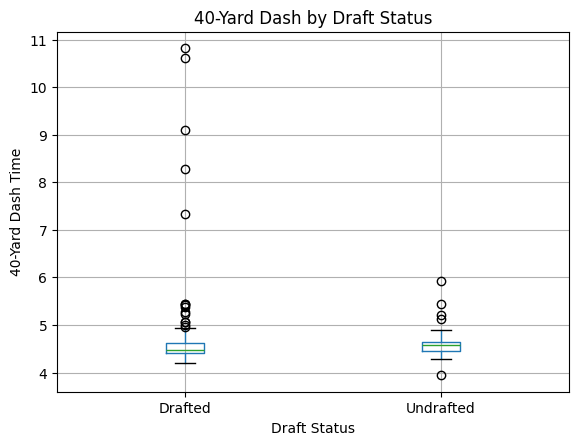

In [12]:
import matplotlib.pyplot as plt

df1.boxplot(column="40-Yard Dash (seconds)", by="Drafted")

plt.title("40-Yard Dash by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("40-Yard Dash Time")
plt.show()

Drafted players generally had slightly faster 40-yard dash times, as shown by the lower median.

The drafted group has more extreme outliers, likely because some data points were entered incorrectly or represent injured/failed runs.

The boxes overlap heavily, suggesting 40-yard dash alone was not enough to determine draft status.

The undrafted group has a tighter spread, while drafted players show more variability because drafted athletes come from many different positions and player types.

## Visualization: Vertical Jump by Draft Status
This boxplot compares vertical jump performance between drafted and undrafted players.


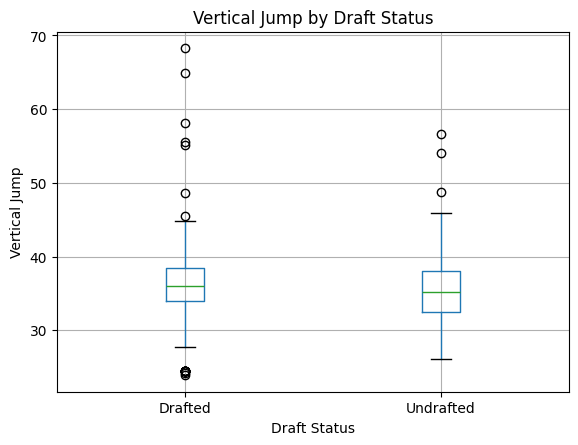

In [13]:
df1.boxplot(column="Vertical (inches)", by="Drafted")

plt.title("Vertical Jump by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Vertical Jump")
plt.show()

Drafted players had a slightly higher median vertical jump, suggesting explosiveness may help draft chances.

The drafted group has more high-end outliers, likely representing elite athletes with exceptional explosiveness.

The large overlap between the boxes suggests vertical jump alone was not a major separator between drafted and undrafted players.

Some extremely high values may be data-entry or formatting issues because jumps near 70 inches are unrealistic.


## Visualization: Bench Press by Draft Status
This boxplot compares bench press reps between drafted and undrafted players.


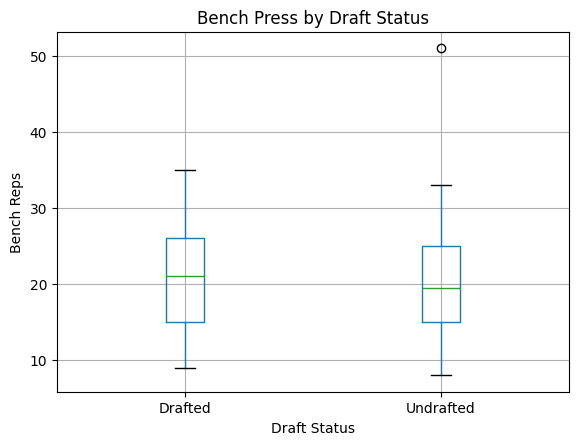

In [14]:
df1.boxplot(column="Bench (reps)", by="Drafted")

plt.title("Bench Press by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Bench Reps")
plt.show()

Drafted players had a slightly higher median bench press, suggesting strength may help draft chances somewhat.

The distributions overlap heavily, meaning bench press alone was not a strong predictor of being drafted.

Undrafted players had the highest outlier, showing elite strength alone did not guarantee getting drafted.

Both groups have similar spreads, suggesting upper-body strength was relatively consistent across prospects.

## Visualization: Broad Jump by Draft Status
This boxplot compares broad jump distance between drafted and undrafted players.


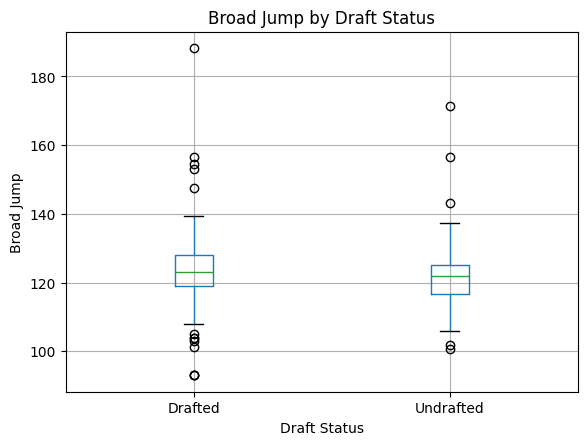

In [15]:
df1.boxplot(column="Broad Jump (inches)", by="Drafted")

plt.title("Broad Jump by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Broad Jump")
plt.show()

Drafted players had a slightly higher median broad jump, suggesting explosiveness may have helped draft chances.

The two groups overlap heavily, meaning broad jump alone was not a strong separator between drafted and undrafted players.

Drafted players had more extreme high-end outliers, likely representing elite athletes.

Some very large broad jump values may be conversion or formatting issues, since jumps near 190 inches are unrealistic.

## Standardize Combine Metrics
This converts combine metrics into z-scores so different drills can be compared on the same scale.


In [16]:
from scipy.stats import zscore

combine_cols = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

# Create Z-score columns
for col in combine_cols:
    df1[col + "_z"] = zscore(df1[col], nan_policy='omit')

## Adjust Direction of Speed-Based Metrics
For timed drills, lower times are better, so these z-scores are flipped to make higher values consistently mean better performance.


In [17]:
df1["40-Yard Dash (seconds)_z"] *= -1
df1["3-Cone (seconds)_z"] *= -1
df1["Shuttle (seconds)_z"] *= -1

## Count Above-Average Combine Events
This counts how many combine events each player performed above average in.


In [18]:
z_cols = [col + "_z" for col in combine_cols]

df1["Above_Average_Events"] = (df1[z_cols] > 0).sum(axis=1)

## Preview Above-Average Event Counts
This displays a few players with their number of above-average combine events.


In [19]:
df1[["Name", "Position", "Above_Average_Events"]].head()

,Name,Position,Above_Average_Events
0,Haynes King,QB,3
1,Joe Fagnano,QB,2
2,Caullin Lacy,WR,3
3,Carson Beck,QB,3
4,Taylen Green,QB,4


## Compare Above-Average Events by Draft Status
This compares the average number of above-average events for drafted and undrafted players.


In [20]:
df1.groupby("Drafted")["Above_Average_Events"].mean()

Drafted
Drafted      3.569565
Undrafted    3.218750
Name: Above_Average_Events, dtype: float64

**Output explanation:** Drafted players average about 3.57 above-average events, while undrafted players average about 3.22. That suggests drafted players performed slightly better overall across combine events, although the difference is not huge.


## Visualization: Above-Average Events by Draft Status
This boxplot compares the distribution of above-average combine events by draft status.


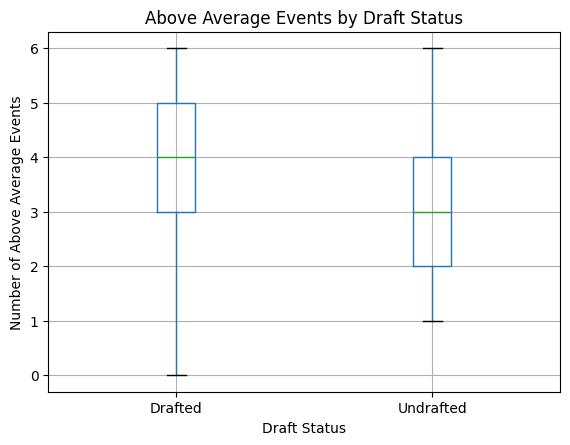

In [21]:
df1.boxplot(column="Above_Average_Events", by="Drafted")

plt.title("Above Average Events by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("Number of Above Average Events")
plt.show()

Drafted players generally had more above-average combine performances than undrafted players.

The drafted median is higher (4 vs 3), suggesting better all-around athleticism may improve draft chances.

Undrafted players show more concentration at lower values, meaning they were less consistently above average across events.

There is still overlap between the groups, so combine performance alone did not determine draft status.

## Position-Based 40-Yard Dash Rank
This ranks players within their own position group for 40-yard dash time.


In [22]:
df1["40_Rank_Pos"] = df1.groupby("Position")["40-Yard Dash (seconds)"] \
    .rank(method="min", ascending=True)

## Position-Based Vertical Jump Rank
This ranks players within their own position group for vertical jump.


In [23]:
df1["Vertical_Rank_Pos"] = df1.groupby("Position")["Vertical (inches)"] \
    .rank(method="min", ascending=False)

## Position-Based Bench Press Rank
This ranks players within their own position group for bench press reps.


In [24]:
df1["Bench_Rank_Pos"] = df1.groupby("Position")["Bench (reps)"] \
    .rank(method="min", ascending=False)

## Position-Based Broad Jump Rank
This ranks players within their own position group for broad jump distance.


In [25]:
df1["Broad_Rank_Pos"] = df1.groupby("Position")["Broad Jump (inches)"] \
    .rank(method="min", ascending=False)

## Position-Based 3-Cone Rank
This ranks players within their own position group for 3-cone time.


In [26]:
df1["Cone_Rank_Pos"] = df1.groupby("Position")["3-Cone (seconds)"] \
    .rank(method="min", ascending=True)

## Position-Based Shuttle Rank
This ranks players within their own position group for shuttle time.


In [27]:
df1["Shuttle_Rank_Pos"] = df1.groupby("Position")["Shuttle (seconds)"] \
    .rank(method="min", ascending=True)

## Preview Position-Based Rankings
This checks the new ranking columns for the first several players.


In [28]:
df1[[
    "Name",
    "Position",
    "40_Rank_Pos",
    "Vertical_Rank_Pos",
    "Bench_Rank_Pos"
]].head(20)

,Name,Position,40_Rank_Pos,Vertical_Rank_Pos,Bench_Rank_Pos
0,Haynes King,QB,13.0,21.0,38.0
1,Joe Fagnano,QB,33.0,18.0,18.0
2,Caullin Lacy,WR,112.0,114.0,6.0
3,Carson Beck,QB,14.0,1.0,30.0
4,Taylen Green,QB,11.0,9.0,14.0
5,Chris Hilton Jr.,WR,44.0,106.0,40.0
6,Behren Morton,QB,11.0,20.0,38.0
7,Eli Stowers,TE,7.0,2.0,52.0
8,Matthew Hibner,TE,10.0,13.0,17.0
9,Noah Whittington,RB,56.0,2.0,26.0


## Position-Based Percentile Rank
This creates a percentile ranking for 40-yard dash performance within each position.


In [29]:
df1["40_Percentile_Pos"] = df1.groupby("Position")["40-Yard Dash (seconds)"] \
    .rank(pct=True, ascending=False)

## Wide Receiver 40-Yard Dash Comparison
This focuses only on wide receivers and compares average 40-yard dash time by draft status.


In [30]:
wr = df1[df1["Position"] == "WR"]

wr.groupby("Drafted")["40-Yard Dash (seconds)"].mean()

Drafted
Drafted      4.441753
Undrafted    4.509750
Name: 40-Yard Dash (seconds), dtype: float64

**Output explanation:** Drafted wide receivers averaged a faster 40-yard dash than undrafted wide receivers. Since lower times are better, this supports the idea that speed matters for wide receivers.


## Visualization: WR 40-Yard Dash by Draft Status
This boxplot compares 40-yard dash times among wide receivers only.


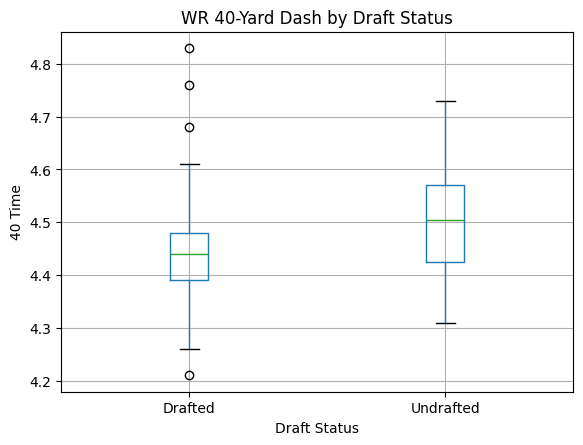

In [31]:
wr.boxplot(column="40-Yard Dash (seconds)", by="Drafted")

plt.title("WR 40-Yard Dash by Draft Status")
plt.suptitle("")
plt.xlabel("Draft Status")
plt.ylabel("40 Time")
plt.show()

Drafted WRs generally had faster 40-yard dash times than undrafted WRs, suggesting speed was an important factor for receivers.

The drafted WR group has a lower median and tighter spread, meaning successful WR prospects were more consistently fast.

Undrafted WRs showed slower times overall and more variability, likely making them less attractive to NFL teams.

There is still some overlap, showing that speed alone did not determine whether a WR was drafted.

## Position-by-Position Metric Averages
This prints drafted and undrafted averages for key combine metrics within each position.


In [32]:
metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

positions = df1["Position"].unique()

for pos in positions:
    
    subset = df1[df1["Position"] == pos]
    
    print(f"\n===== {pos} =====")
    
    for metric in metrics:
        
        drafted_mean = subset[subset["Drafted"] == "Drafted"][metric].mean()
        undrafted_mean = subset[subset["Drafted"] == "Undrafted"][metric].mean()
        
        print(f"{metric}")
        print(f"Drafted Avg: {drafted_mean:.2f}")
        print(f"Undrafted Avg: {undrafted_mean:.2f}")
        print()


===== QB =====
40-Yard Dash (seconds)
Drafted Avg: 5.32
Undrafted Avg: 4.72

Vertical (inches)
Drafted Avg: 37.26
Undrafted Avg: 37.20

Bench (reps)
Drafted Avg: 17.55
Undrafted Avg: 14.50

Broad Jump (inches)
Drafted Avg: 123.95
Undrafted Avg: 124.35

3-Cone (seconds)
Drafted Avg: 7.41
Undrafted Avg: 7.58

Shuttle (seconds)
Drafted Avg: 4.71
Undrafted Avg: 4.52


===== WR =====
40-Yard Dash (seconds)
Drafted Avg: 4.44
Undrafted Avg: 4.51

Vertical (inches)
Drafted Avg: 37.12
Undrafted Avg: 36.37

Bench (reps)
Drafted Avg: 18.70
Undrafted Avg: 18.75

Broad Jump (inches)
Drafted Avg: 125.29
Undrafted Avg: 123.68

3-Cone (seconds)
Drafted Avg: 6.91
Undrafted Avg: 6.90

Shuttle (seconds)
Drafted Avg: 4.23
Undrafted Avg: 4.33


===== TE =====
40-Yard Dash (seconds)
Drafted Avg: 4.74
Undrafted Avg: 4.74

Vertical (inches)
Drafted Avg: 35.06
Undrafted Avg: 34.15

Bench (reps)
Drafted Avg: 25.30
Undrafted Avg: 26.00

Broad Jump (inches)
Drafted Avg: 119.70
Undrafted Avg: 117.42

3-Cone (seco

**Output explanation:** This output compares drafted and undrafted averages separately for each position. It shows that the importance of a combine metric can differ by position, which is why position-specific analysis is useful.


## Correlation by Position and Metric
This calculates how each combine metric relates to Overall Pick within each actual position using the full Scouting Combine dataset, not only the matched skill-player dataset.


In [33]:
from IPython.display import display

# IMPORTANT: use df3 here because df1 / All Matches mainly contains skill-position matches.
# df3 is the full scouting combine dataset, so it includes OL and defensive players too.
position_df = df3.copy()

# Clean position labels so similar positions are named consistently
position_df["Position"] = position_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT",
    "OL": "OT",
    "DB": "CB",
    "ILB": "LB",
    "OLB": "LB"
})

metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

positions = sorted(position_df["Position"].dropna().unique())

results = []

for pos in positions:
    subset = position_df[position_df["Position"] == pos]
    
    for metric in metrics:
        corr = subset[metric].corr(subset["Overall Pick"])
        
        results.append({
            "Position": pos,
            "Metric": metric,
            "Correlation with Overall Pick": round(corr, 3),
            "Players Used": subset[[metric, "Overall Pick"]].dropna().shape[0]
        })

results_df = pd.DataFrame(results)

display(results_df)


/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning:

,Position,Metric,Correlation with Overall Pick,Players Used
0,C,40-Yard Dash (seconds),-0.206,33
1,C,Vertical (inches),-0.069,33
2,C,Bench (reps),0.227,33
3,C,Broad Jump (inches),-0.089,33
4,C,3-Cone (seconds),-0.021,33
...,...,...,...,...
109,WR,Vertical (inches),-0.155,184
110,WR,Bench (reps),-0.049,184
111,WR,Broad Jump (inches),-0.150,184
112,WR,3-Cone (seconds),0.052,184


**Output explanation:** This now uses the full combine dataset, so the position rows should include offensive line and defensive positions such as C, OT, OG, EDGE, DE, DT, LB, CB, and S when those positions exist in the dataset. The `Players Used` column shows how many players had enough data for that specific metric/correlation.


## Correlation Heatmap for Selected Variables
This visualizes relationships among key performance, measurement, and draft variables.


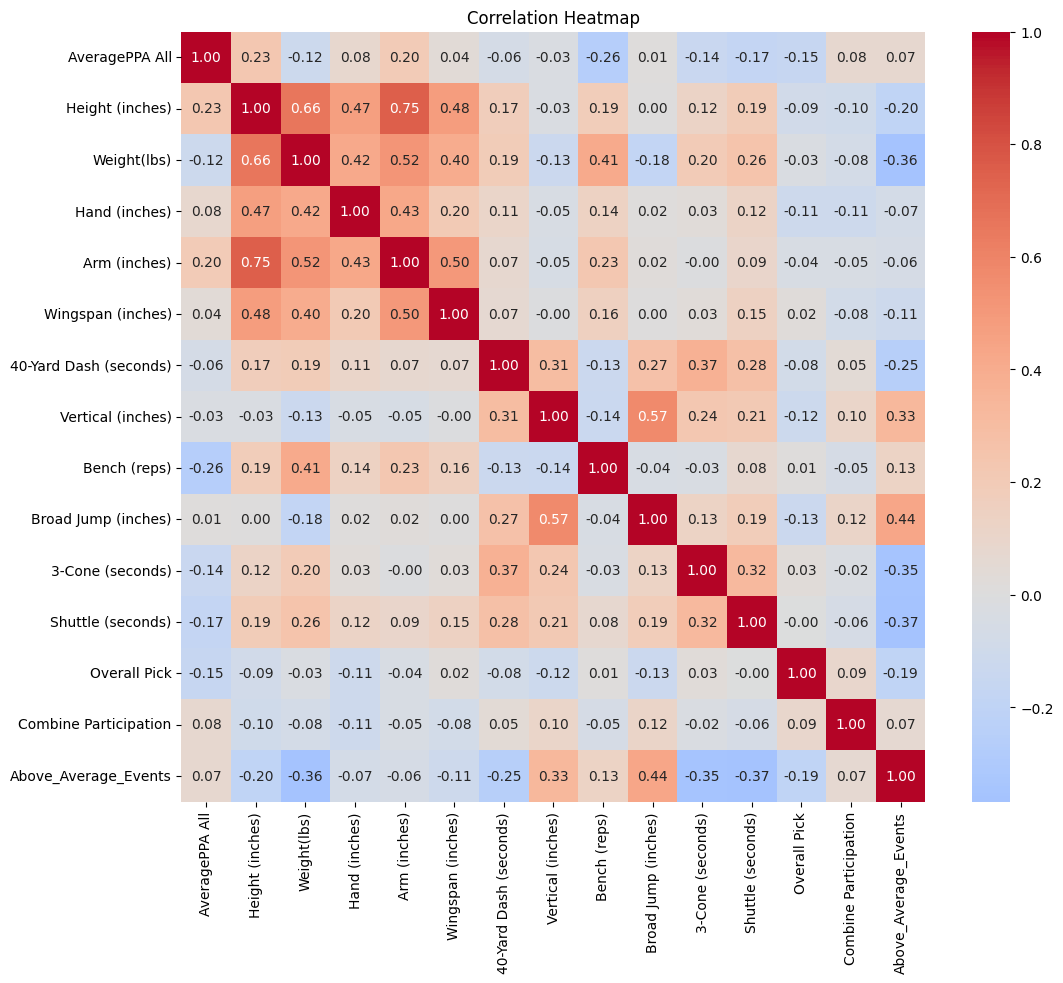

In [34]:
selected_cols = [
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Overall Pick",
    "Combine Participation",
    "Above_Average_Events"
]

corr_matrix = df1[selected_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Matrix by Actual Position
This creates a table showing correlations between each combine metric and Overall Pick for every actual position in the full combine dataset.


In [35]:
# IMPORTANT: use the full combine dataset, not df1 / All Matches.
# df1 mostly contains QB/RB/WR/TE matches, which is why the old output only showed those positions.
position_df = df3.copy()

# Clean position labels so similar positions are named consistently
position_df["Position"] = position_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT",
    "OL": "OT",
    "DB": "CB",
    "ILB": "LB",
    "OLB": "LB"
})

metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

# Recreate Above_Average_Events inside the full combine dataset
available_combine_cols = [col for col in metrics if col in position_df.columns]
for col in available_combine_cols:
    position_df[col + "_z"] = zscore(position_df[col], nan_policy="omit")

# Timed drills are better when lower, so flip those z-scores
for col in ["40-Yard Dash (seconds)", "3-Cone (seconds)", "Shuttle (seconds)"]:
    if col + "_z" in position_df.columns:
        position_df[col + "_z"] *= -1

z_cols = [col + "_z" for col in available_combine_cols]
position_df["Above_Average_Events"] = (position_df[z_cols] > 0).sum(axis=1)

metrics_for_matrix = metrics + ["Above_Average_Events"]
positions = sorted(position_df["Position"].dropna().unique())

results = []

for pos in positions:
    subset = position_df[position_df["Position"] == pos]
    row = {"Position": pos}
    
    for metric in metrics_for_matrix:
        row[metric] = subset[metric].corr(subset["Overall Pick"])
    
    results.append(row)

position_matrix = pd.DataFrame(results)

position_matrix


/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning:

,Position,40-Yard Dash (seconds),Vertical (inches),Bench (reps),Broad Jump (inches),3-Cone (seconds),Shuttle (seconds),Above_Average_Events
0,C,-0.205522,-0.069492,0.227441,-0.089081,-0.021068,0.366420,0.104288
1,CB,0.286043,-0.223615,0.082928,-0.231044,-0.072329,0.025998,-0.038855
2,DE,-0.257183,-0.049439,0.005377,0.224031,0.208836,-0.106299,0.097946
3,DT,0.240146,-0.129201,-0.071602,-0.135148,-0.025291,0.013473,-0.110864
4,EDGE,0.270924,-0.193654,-0.085675,-0.130997,0.093943,0.037966,-0.256033
5,FB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,G,0.408856,-0.268277,-0.289029,-0.196445,0.454186,0.431683,-0.122011
7,IOL,0.001394,0.043220,-0.171747,-0.081643,0.222559,-0.320403,0.141213
8,K,0.252789,-0.164668,0.170324,-0.249651,0.148442,0.125756,-0.333036
9,LB,0.166254,-0.071138,0.012078,-0.080612,0.098213,0.026462,-0.179070


## Heatmap of Actual Position-Level Correlations
This visualizes which combine metrics are more or less related to draft position across all actual positions in the full combine dataset.


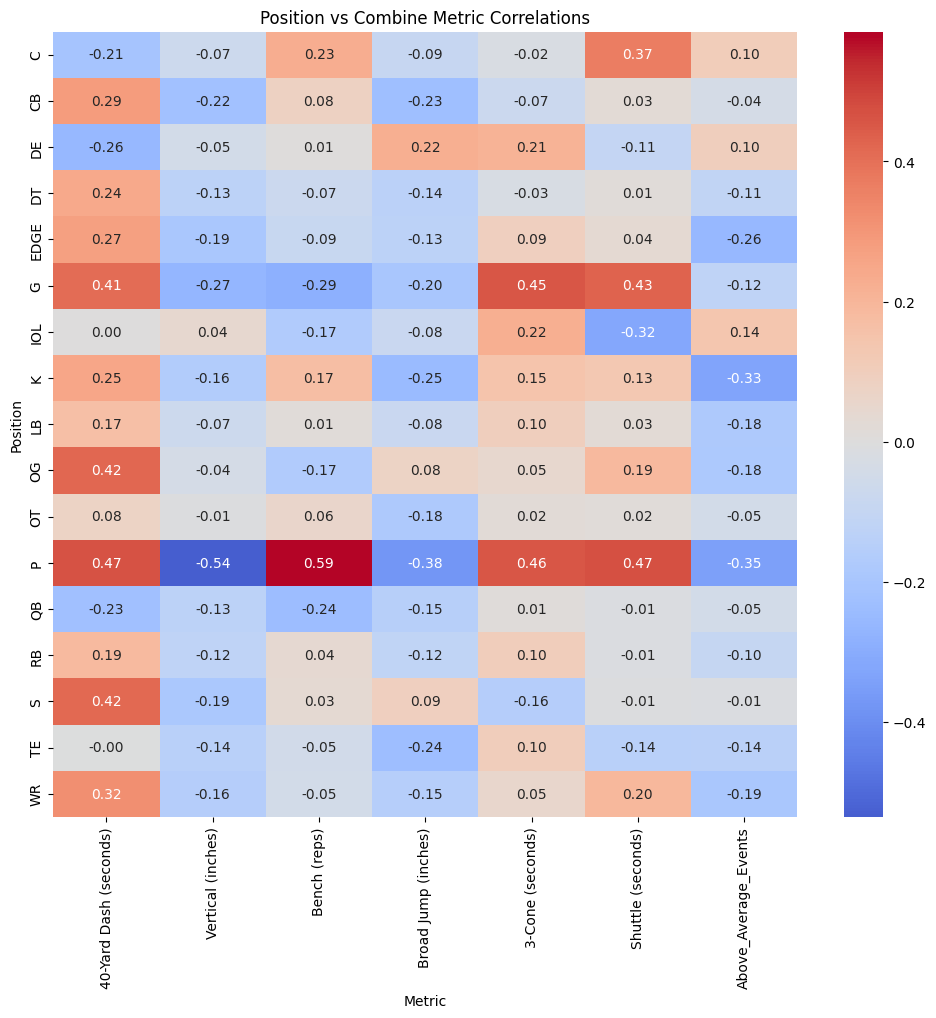

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove positions with tiny sample sizes
position_matrix = position_matrix[
    ~position_matrix["Position"].isin(["LS", "FB"])
]

heatmap_data = position_matrix.set_index("Position")

plt.figure(figsize=(12, max(8, len(heatmap_data) * 0.6)))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Position vs Combine Metric Correlations")
plt.xlabel("Metric")
plt.ylabel("Position")

plt.show()


This output now uses the full Scouting Combine dataset instead of the matched player-ranking dataset, so it should include every actual position available in the combine data rather than only QB, RB, WR, and TE.


## Principal Component Analysis: Factor Loadings
This uses PCA to condense related physical and combine variables into broader factors.


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

fa_vars = df1[[
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]].dropna()

scaled_vars = StandardScaler().fit_transform(fa_vars)

pca = PCA(n_components=4)
pca.fit(scaled_vars)

loadings = pd.DataFrame(
    pca.components_.T,
    index=fa_vars.columns,
    columns=["Factor1", "Factor2", "Factor3", "Factor4"]
)

loadings

,Factor1,Factor2,Factor3,Factor4
Height (inches),0.483807,-0.038340,-0.123187,-0.171393
Weight(lbs),0.456372,-0.089074,0.264785,0.082491
Hand (inches),0.337555,-0.046640,-0.115140,-0.180993
Arm (inches),0.445954,-0.100451,-0.292148,-0.106303
Wingspan (inches),0.350486,-0.047831,-0.220278,-0.036066
40-Yard Dash (seconds),0.150308,0.437201,0.193696,-0.294237
Vertical (inches),-0.008738,0.525744,-0.325644,0.157012
Bench (reps),0.211327,-0.184924,0.114569,0.820226
Broad Jump (inches),0.006691,0.476224,-0.473113,0.272468
3-Cone (seconds),0.125306,0.377066,0.522457,-0.074177


Factor1 appears to represent overall body size because Height, Weight, Arm Length, and Wingspan all load highly on it.

Factor2 seems to capture explosiveness/athleticism since Vertical Jump, Broad Jump, and 40-yard dash load strongly here.

Factor3 looks related to agility/change of direction because 3-Cone and Shuttle have the strongest loadings.

Factor4 is heavily driven by Bench Press, suggesting it mainly represents upper-body strength.

This shows many combine metrics cluster together, which supports your earlier multicollinearity concerns.\

## Principal Component Analysis: Explained Variance
This shows how much variation each PCA factor explains.


In [38]:
explained = pd.DataFrame({
    "Factor": ["Factor1", "Factor2", "Factor3", "Factor4"],
    "Explained Variance": pca.explained_variance_ratio_
})

explained

,Factor,Explained Variance
0,Factor1,0.294138
1,Factor2,0.196253
2,Factor3,0.103245
3,Factor4,0.087973


Factor1 explains the most variance (~29.4%), meaning body size measurements were the strongest overall pattern in the combine data.

Factor2 explains about 19.6% of the variance, suggesting explosiveness/athleticism was the second most important grouping of metrics.

Factors 3 and 4 explain much less variance, meaning agility and strength contributed less to overall variation in the dataset.

Together, the four factors explain about 68% of the total variance, meaning they capture most of the important information in the combine metrics.

## Prepare Regression Dataset
This selects the variables used for the final exact-pick OLS regression model.


In [39]:
reg_df = df1[[
    "Overall Pick",
    "AveragePPA All",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position"
]].dropna()

## Convert Position to Dummy Variables
This converts categorical position values into numeric dummy variables for regression modeling.


In [40]:
reg_df = pd.get_dummies(
    reg_df,
    columns=["Position"],
    drop_first=True
)

## Import Regression Libraries
This imports the statsmodels package used for OLS regression.


In [41]:
import pandas as pd
import statsmodels.api as sm

## Define Offensive Line Positions
This creates a list of positions that will be grouped as offensive line.


In [42]:
oline_positions = ["OT", "OG", "C"]

## Define Secondary Positions
This creates a list of positions that will be grouped as defensive backs.


In [43]:
secondary_positions = ["CB", "S"]

## Define Front Seven Positions
This creates a list of defensive line and edge positions.


In [44]:
front_positions = ["EDGE", "DE", "DT"]

## Create Actual Position Variable
This keeps each position separate instead of grouping players into only Skill, OL, Front, Secondary, LB, and Other.


In [45]:
# ==========================================
# ACTUAL POSITIONS
# ==========================================

# Clean position labels so similar positions are named consistently
df1["Position"] = df1["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT",
    "OL": "OT",
    "DB": "CB",
    "ILB": "LB",
    "OLB": "LB"
})

# Keep actual positions separate instead of grouping only QB/RB/WR/TE as skill players
df1["Position_Group"] = df1["Position"]

print(df1["Position_Group"].value_counts())


Position_Group
WR    137
RB     82
TE     64
QB     43
Name: count, dtype: int64


## Build Final Exact-Pick OLS Dataset
This creates the dataset used for the final OLS model predicting Overall Pick for drafted players only.


In [46]:
model_df = df1[df1["Overall Pick"] != 300][[
    "Overall Pick",
    "AveragePPA All",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Broad Jump (inches)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

## Add Position Group Dummies for OLS
This converts position groups into numeric dummy variables and prepares the model data for regression.


In [47]:
model_df = pd.get_dummies(
    model_df,
    columns=["Position_Group"],
    drop_first=True
)

model_df = model_df.astype(float)

## Confirm Final OLS Variables
This prints the exact variables included in the final exact-pick OLS dataset.


In [48]:
print(model_df.columns)

Index(['Overall Pick', 'AveragePPA All', 'Height (inches)', 'Weight(lbs)',
       '40-Yard Dash (seconds)', 'Vertical (inches)', 'Broad Jump (inches)',
       'Shuttle (seconds)', 'Position_Group_RB', 'Position_Group_TE',
       'Position_Group_WR'],
      dtype='str')


## Check Position Counts Across Datasets
This compares how many players are listed at each position in the three datasets.


In [49]:
# Check positions in each original dataset
print("df1/master:")
print(df1["Position"].value_counts())

print("\ndf2/player rankings:")
print(df2["Position"].value_counts())

print("\ndf3/combine:")
print(df3["Position"].value_counts())

df1/master:
Position
WR    137
RB     82
TE     64
QB     43
Name: count, dtype: int64

df2/player rankings:
Position
WR    5223
RB    3150
TE    2084
QB    1918
FB      34
Name: count, dtype: int64

df3/combine:
Position
WR      184
CB      146
EDGE    127
RB      107
LB      106
OT      103
TE       84
DL       72
QB       59
SAF      47
DT       43
OG       35
C        32
IOL      32
G        24
DB       22
S        21
DE       13
K        10
P         7
FB        1
LS        1
OC        1
Name: count, dtype: int64


**Output explanation:** This confirms that the matched dataset mainly contains QB, RB, WR, and TE, while the broader datasets include more positions. That matters because the final model using the combine dataset has wider position coverage.


## Reload Full Datasets for Full-Position Modeling
This reloads the original CSV files so later models can use the full combine dataset.


In [50]:
import pandas as pd

df1 = pd.read_csv("All Matches.csv", encoding="latin1")
df2 = pd.read_csv("All NCAA Player Rankings.csv", encoding="latin1")
df3 = pd.read_csv("All NFL Scouting Combine Results.csv", encoding="latin1")

## Confirm Position Coverage After Reloading
This checks position counts again after reloading the datasets.


In [51]:
print(df1["Position"].value_counts())
print(df2["Position"].value_counts())
print(df3["Position"].value_counts())

Position
WR    137
RB     82
TE     64
QB     43
Name: count, dtype: int64
Position
WR    5223
RB    3150
TE    2084
QB    1918
FB      34
Name: count, dtype: int64
Position
WR      184
CB      146
EDGE    127
RB      107
LB      106
OT      103
TE       84
DL       72
QB       59
SAF      47
DT       43
OG       35
C        32
IOL      32
G        24
DB       22
S        21
DE       13
K        10
P         7
FB        1
LS        1
OC        1
Name: count, dtype: int64


## Create Position Groups in the Combine Dataset
This prepares the full combine dataset for modeling by creating broader position groups.


In [52]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use combine dataset because it includes all positions
all_df = df3.copy()

# Clean position labels so similar positions are named consistently
all_df["Position"] = all_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT",
    "OL": "OT",
    "DB": "CB",
    "ILB": "LB",
    "OLB": "LB"
})

# Keep drafted players only for the exact-pick OLS model
all_df = all_df[all_df["Overall Pick"] != 300].copy()

# Keep actual positions separate: QB, RB, WR, TE, OT, OG, C, EDGE, DE, DT, LB, CB, S, etc.
all_df["Position_Group"] = all_df["Position"]

print("All drafted positions included before dropping missing model values:")
print(all_df["Position_Group"].value_counts())

ols_required_cols = [
    "Overall Pick",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Position_Group"
]

print("\nPosition coverage after the OLS variables are available:")
print(all_df[ols_required_cols].dropna()["Position_Group"].value_counts())


All drafted positions included before dropping missing model values:
Position_Group
CB      129
WR      127
EDGE     90
DT       89
OT       82
RB       73
LB       73
TE       61
S        53
QB       45
IOL      28
C        24
OG       21
G        15
DE       10
K         6
P         3
Name: count, dtype: int64

Position coverage after the OLS variables are available:
Position_Group
CB      129
WR      127
EDGE     90
DT       89
OT       82
RB       73
LB       73
TE       61
S        53
QB       45
IOL      28
C        24
OG       21
G        15
DE       10
K         6
P         3
Name: count, dtype: int64


## Final OLS Model: Predicting Exact Overall Pick
This OLS regression estimates how selected combine metrics and position groups relate to exact Overall Pick.


In [53]:
clean_df = all_df[[
    "Overall Pick",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Position_Group"
]].dropna()

# Convert actual positions into dummy variables
clean_df = pd.get_dummies(
    clean_df,
    columns=["Position_Group"],
    drop_first=True
)

clean_df = clean_df.astype(float)

X = clean_df.drop(columns=["Overall Pick"])
y = clean_df["Overall Pick"]

X = sm.add_constant(X)

clean_model = sm.OLS(y, X).fit()

print(clean_model.summary())


                            OLS Regression Results                            
Dep. Variable:           Overall Pick   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     3.176
Date:                Tue, 12 May 2026   Prob (F-statistic):           3.48e-06
Time:                        14:23:27   Log-Likelihood:                -5261.3
No. Observations:                 929   AIC:                         1.056e+04
Df Residuals:                     908   BIC:                         1.067e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    376

This model now uses every actual position from the full combine dataset rather than only QB/RB/WR/TE.

The R² may still be low because exact pick prediction is extremely difficult. NFL draft position depends on film, injuries, interviews, production, scheme fit, team needs, and many other factors beyond combine testing.

The position dummy variables should now include offensive line and defensive positions when those positions have complete model data.


## Multicollinearity Check: VIF
This checks whether predictors in the OLS model are highly correlated with each other.


In [54]:
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                  Variable         VIF
1   40-Yard Dash (seconds)  139.661142
0              Weight(lbs)  125.783252
2        Vertical (inches)   61.347109
3             Bench (reps)   12.141648
4        Position_Group_CB    6.010575
19       Position_Group_WR    5.833427
6        Position_Group_DT    4.507684
13       Position_Group_OT    4.482596
7      Position_Group_EDGE    4.211336
16       Position_Group_RB    3.602189
11       Position_Group_LB    3.577263
18       Position_Group_TE    3.114776
17        Position_Group_S    2.962423
15       Position_Group_QB    2.905593
9       Position_Group_IOL    2.156654
12       Position_Group_OG    1.853861
8         Position_Group_G    1.620850
5        Position_Group_DE    1.350583
10        Position_Group_K    1.220872
14        Position_Group_P    1.108795


The combine metrics show extremely high multicollinearity, especially 40-yard dash (120.6) and weight (83.5).

VIF values above 10 are usually considered problematic, so several variables here are highly redundant with one another.

This likely happens because many combine metrics measure similar athletic traits. For example, bigger players may naturally have different speed and strength profiles.

The position group variables have much lower VIFs, meaning position categories were relatively independent predictors.

## Random Forest Model: Draft Round Classification
This builds a machine learning model to predict draft round categories from player data.


In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

all_df = df3.copy()

all_df["Position"] = all_df["Position"].replace({
    "SAF": "S",
    "OC": "C",
    "DL": "DT",
    "OL": "OT",
    "DB": "CB",
    "ILB": "LB",
    "OLB": "LB"
})

all_df["Pick_Bucket"] = pd.cut(
    all_df["Overall Pick"],
    bins=[0, 32, 96, 160, 224, 300],
    labels=["Round1", "Rounds2_3", "Rounds4_5", "Rounds6_7", "Undrafted"],
    include_lowest=True
)

all_df["Position_Group"] = all_df["Position"]

print("All positions included before dropping missing values:")
print(all_df["Position_Group"].value_counts())

model_df = all_df[[
    "Pick_Bucket",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

print("\nPositions included after dropping missing model values:")
print(model_df["Position_Group"].value_counts())

model_df = pd.get_dummies(model_df, columns=["Position_Group"], drop_first=True)

X = model_df.drop(columns=["Pick_Bucket"])
y = model_df["Pick_Bucket"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

All positions included before dropping missing values:
Position_Group
WR      184
CB      168
EDGE    127
DT      115
RB      107
LB      106
OT      103
TE       84
S        68
QB       59
OG       35
C        33
IOL      32
G        24
DE       13
K        10
P         7
FB        1
LS        1
Name: count, dtype: int64

Positions included after dropping missing model values:
Position_Group
WR      184
CB      168
EDGE    127
DT      115
RB      107
LB      106
OT      103
TE       84
S        68
QB       59
OG       35
C        33
IOL      32
G        24
DE       13
K        10
P         7
FB        1
LS        1
Name: count, dtype: int64


Accuracy: 0.36875

Confusion Matrix:
[[  0   5   2   0  25]
 [  0   8   6   0  49]
 [  0   0   5   0  57]
 [  0   1   6   1  44]
 [  0   2   4   1 104]]

Classification Report:
              precision    recall  f1-score   support

      Round1       0.00      0.00      0.00        32
   Rounds2_3       0.50      0.13      0.20        63
   Rounds4_5       0.22      0.08      0.12        62
   Rounds6_7       0.50      0.02      0.04        52
   Undrafted       0.37      0.94      0.53       111

    accuracy                           0.37       320
   macro avg       0.32      0.23      0.18       320
weighted avg       0.35      0.37      0.25       320



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

The model achieved about 36% accuracy, which is modest but better than random guessing across five classes.

The model performed best at identifying undrafted players, with very high recall (0.92), meaning it correctly identified most undrafted prospects.

The model struggled badly with Round 1 predictions, failing to correctly classify any first-round players.

Many drafted players were incorrectly predicted as undrafted, suggesting the model was biased toward the largest class.

This likely happened because draft outcomes are highly imbalanced and depend on many non-statistical factors beyond combine data.

## Random Forest Feature Importance
This shows which variables the random forest model relied on most when making predictions.


In [56]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
2,40-Yard Dash (seconds),0.151841
5,Broad Jump (inches),0.123090
1,Weight(lbs),0.119597
3,Vertical (inches),0.117972
0,Height (inches),0.107282
6,3-Cone (seconds),0.093950
7,Shuttle (seconds),0.082503
4,Bench (reps),0.078790
21,Position_Group_QB,0.018657
25,Position_Group_WR,0.016922


This section now uses actual position dummy variables instead of one broad skill-player group. If a position does not appear here, it was removed only because that position was missing one or more required model values after `.dropna()`.


## Tuned Random Forest Model
This adjusts the random forest settings to reduce overfitting and improve generalization.


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.33125

Confusion Matrix:
[[15  7  3  3  4]
 [18 12 12  6 15]
 [ 8  8 17 10 19]
 [ 8  6 12  9 17]
 [ 8 17 20 13 53]]

Classification Report:
              precision    recall  f1-score   support

      Round1       0.26      0.47      0.34        32
   Rounds2_3       0.24      0.19      0.21        63
   Rounds4_5       0.27      0.27      0.27        62
   Rounds6_7       0.22      0.17      0.19        52
   Undrafted       0.49      0.48      0.48       111

    accuracy                           0.33       320
   macro avg       0.30      0.32      0.30       320
weighted avg       0.33      0.33      0.33       320



The tuned Random Forest achieved about 32% accuracy, which is similar to the earlier model and shows predicting draft rounds remains difficult.

Unlike the earlier model, this version did a much better job predicting Round 1 players (34% recall instead of 0%).

The model was more balanced across classes and no longer overwhelmingly predicted players as undrafted.

Undrafted players were still predicted best overall, likely because they were the largest class in the dataset.

The lower bias toward “Undrafted” suggests tuning helped the model generalize better across draft rounds.

## Visualization: Feature Importance
This chart displays which features were most important in the random forest model.


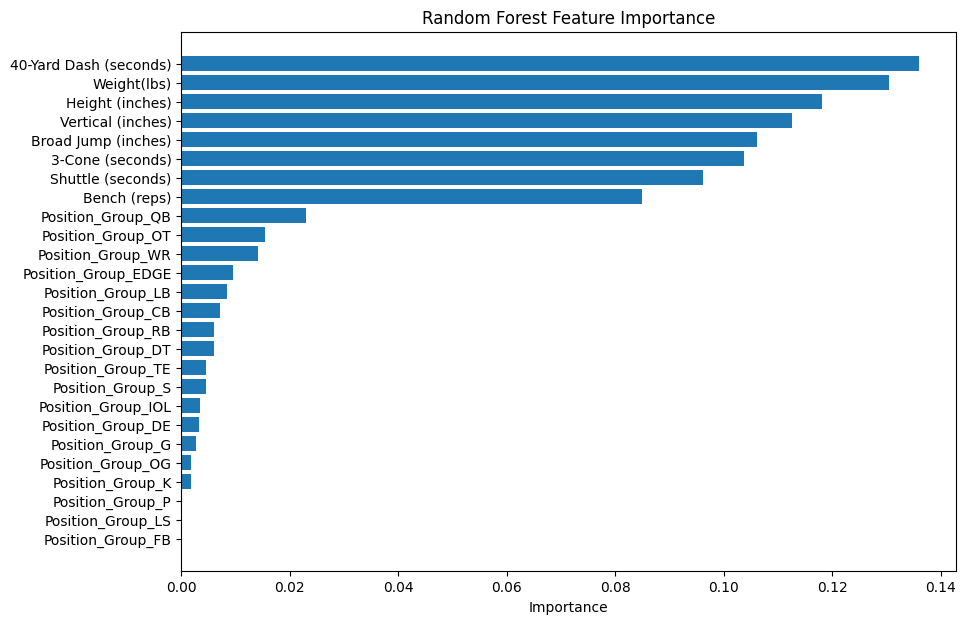

In [58]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10,7))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

This section now uses actual position dummy variables instead of one broad skill-player group. If a position does not appear here, it was removed only because that position was missing one or more required model values after `.dropna()`.


## Compare Training and Testing Accuracy
This compares model accuracy on training data versus unseen testing data.


In [59]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7251828631138976
Testing Accuracy: 0.33125


The Random Forest performed much better on the training data (78%) than the testing data (32%).

This suggests the model is likely overfitting, meaning it learned patterns specific to the training set that did not generalize well to new data.

The large gap between training and testing accuracy indicates the model may be too complex relative to the amount of data available.

Despite overfitting, the testing accuracy still suggests the model captured some meaningful relationships between combine metrics and draft outcomes.

## More Conservative Random Forest Model
This tries a more restricted random forest model to reduce overfitting.


In [60]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, test_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Training Accuracy: 0.45454545454545453
Testing Accuracy: 0.3

Classification Report:
              precision    recall  f1-score   support

      Round1       0.24      0.53      0.33        32
   Rounds2_3       0.20      0.16      0.18        63
   Rounds4_5       0.22      0.24      0.23        62
   Rounds6_7       0.21      0.15      0.18        52
   Undrafted       0.49      0.41      0.45       111

    accuracy                           0.30       320
   macro avg       0.27      0.30      0.27       320
weighted avg       0.31      0.30      0.30       320



The gap between training accuracy (46%) and testing accuracy (29%) is smaller now, suggesting less overfitting than the earlier Random Forest.

The model became better at identifying Round 1 players (44% recall), but overall testing accuracy dropped slightly.

Undrafted players were still predicted best overall, likely because they were the largest group in the dataset.

The relatively low accuracy across all classes shows draft outcomes are still difficult to predict using combine metrics alone.

## Cross-Validation Accuracy
This evaluates the random forest model across multiple train/test splits for a more stable accuracy estimate.


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.3125     0.28515625 0.29803922 0.29411765 0.21176471]
Average CV Accuracy: 0.2803155637254902


The cross-validation scores vary quite a bit across folds, suggesting the model’s performance is somewhat unstable depending on the sample split.

The average cross-validation accuracy was about 27%, which is slightly lower than the earlier test accuracy estimates.

This suggests the model may not generalize as well to completely unseen data as initially expected.

The results reinforce that predicting NFL draft outcomes using combine metrics alone is difficult and somewhat inconsistent.

## Convert Overall Pick to Draft Round
This function converts exact pick number into draft round categories, with 300 treated as Undrafted.


In [62]:
def pick_to_round(pick):
    if pick == 300:
        return "Undrafted"
    elif pick <= 32:
        return "Round1"
    elif pick <= 64:
        return "Round2"
    elif pick <= 100:
        return "Round3"
    elif pick <= 138:
        return "Round4"
    elif pick <= 176:
        return "Round5"
    elif pick <= 224:
        return "Round6"
    else:
        return "Round7"

all_df["Draft_Round"] = all_df["Overall Pick"].apply(pick_to_round)

## Prepare Features for Round Prediction
This selects the predictors and target variable used for draft round classification.


In [63]:
features = [
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position_Group"
]

model_df = all_df[features + ["Draft_Round"]].dropna()

print("Positions included in the final draft-round model:")
print(model_df["Position_Group"].value_counts())

# Convert actual positions into dummy variables
model_df = pd.get_dummies(
    model_df,
    columns=["Position_Group"],
    drop_first=True
)

X = model_df.drop(columns=["Draft_Round"])
y = model_df["Draft_Round"]


Positions included in the final draft-round model:
Position_Group
WR      184
CB      168
EDGE    127
DT      115
RB      107
LB      106
OT      103
TE       84
S        68
QB       59
OG       35
C        33
IOL      32
G        24
DE       13
K        10
P         7
FB        1
LS        1
Name: count, dtype: int64


## Split Data into Training and Testing Sets
This separates the data into training and testing sets while preserving the draft-round distribution.


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## Train Final Round Classification Model
This fits the random forest model using the selected features and draft round labels.


In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

## Evaluate Final Round Classification Model
This prints training accuracy, testing accuracy, a confusion matrix, and a classification report.


In [66]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy:", rf_model.score(X_test, y_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.3730407523510972
Testing Accuracy: 0.16875

Confusion Matrix:
[[12  8  3  3  0  1  1  4]
 [10  5  1  4  4  1  5  2]
 [ 5  9  3  3  6  3  4  2]
 [ 6  6  2  5 10  3  1  4]
 [ 2  3  4  4  7  1  9  6]
 [ 6  2  2  6  7  2  5  7]
 [ 4  4  3  0  6  0  3  4]
 [11 11  6  4 17  1 20 17]]

Classification Report:
              precision    recall  f1-score   support

      Round1       0.21      0.38      0.27        32
      Round2       0.10      0.16      0.12        32
      Round3       0.12      0.09      0.10        35
      Round4       0.17      0.14      0.15        37
      Round5       0.12      0.19      0.15        36
      Round6       0.17      0.05      0.08        37
      Round7       0.06      0.12      0.08        24
   Undrafted       0.37      0.20      0.26        87

    accuracy                           0.17       320
   macro avg       0.17      0.17      0.15       320
weighted avg       0.20      0.17      0.17       320



Predicting exact draft rounds was much harder than predicting broader round groups, as shown by the low testing accuracy (17%).

The model performed best on Round 1 and Undrafted players, but struggled heavily with the middle rounds.

Many predictions were spread across nearby rounds, suggesting the model could identify general draft range better than exact round.

The smaller gap between training and testing accuracy suggests less overfitting, but overall predictive power remained weak.

This reinforces that combine metrics alone are not enough to precisely predict NFL draft outcomes.

## Final Round Model Feature Importance
This shows which variables were most important in the final draft-round random forest model.


In [67]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

                   Feature  Importance
2   40-Yard Dash (seconds)    0.126253
3        Vertical (inches)    0.125311
5      Broad Jump (inches)    0.116712
1              Weight(lbs)    0.109196
7        Shuttle (seconds)    0.105910
6         3-Cone (seconds)    0.105344
0          Height (inches)    0.099412
4             Bench (reps)    0.084992
21       Position_Group_QB    0.028265
16       Position_Group_LB    0.018988
19       Position_Group_OT    0.018133
14      Position_Group_IOL    0.014113
25       Position_Group_WR    0.009071
8        Position_Group_CB    0.007552
10       Position_Group_DT    0.006810
23        Position_Group_S    0.005574
11     Position_Group_EDGE    0.004893
18       Position_Group_OG    0.004835
22       Position_Group_RB    0.003661
24       Position_Group_TE    0.002916
13        Position_Group_G    0.002059
9        Position_Group_DE    0.000000
17       Position_Group_LS    0.000000
15        Position_Group_K    0.000000
12       Position_Group_F

In this final draft-round Random Forest model, explosiveness metrics became the most important predictors.

Broad jump was the top feature, followed closely by the 40-yard dash and vertical jump, suggesting lower-body explosiveness mattered most in the model.

Agility drills (shuttle and 3-cone) also had meaningful importance, while bench press remained one of the weaker combine predictors.

Position group variables again had very low importance, reinforcing that athletic testing carried more predictive value than broad positional categories.

Compared to earlier models, the importance scores are more balanced across metrics, suggesting the tuned model relied less heavily on one single feature.

## Convert Draft Rounds to Numeric Values
This maps Round 1 through Undrafted into numeric values so round can be modeled with OLS.


In [68]:
round_map = {
    "Round1": 1,
    "Round2": 2,
    "Round3": 3,
    "Round4": 4,
    "Round5": 5,
    "Round6": 6,
    "Round7": 7,
    "Undrafted": 8
}

all_df["Draft_Round_Num"] = all_df["Draft_Round"].map(round_map)

## Final OLS Model: Predicting Draft Round Number
This OLS regression estimates how selected metrics and position groups relate to draft round number.


In [69]:
import pandas as pd
import statsmodels.api as sm

all_df = df3.copy()
all_df = all_df[all_df["Overall Pick"] != 300].copy()

all_df["Position"] = all_df["Position"].replace({
    "SAF": "S",
    "DB": "CB",
    "OC": "C",
    "G": "OG",
    "OL": "OT",
    "OG": "IOL",
    "C": "IOL",
    "DL": "DT",
    "DE": "EDGE",
    "OLB": "EDGE",
    "ILB": "LB"
})

def pick_to_round_num(pick):
    if pick <= 32:
        return 1
    elif pick <= 64:
        return 2
    elif pick <= 100:
        return 3
    elif pick <= 138:
        return 4
    elif pick <= 176:
        return 5
    elif pick <= 224:
        return 6
    else:
        return 7

all_df["Draft_Round_Num"] = all_df["Overall Pick"].apply(pick_to_round_num)
all_df["Position_Group"] = all_df["Position"]

ols_df = all_df[[
    "Draft_Round_Num",
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Position_Group"
]].dropna()

ols_df = pd.get_dummies(
    ols_df,
    columns=["Position_Group"],
    drop_first=True
)

X = ols_df.drop(columns=["Draft_Round_Num"])
y = ols_df["Draft_Round_Num"]

X = X.astype(float)
X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:        Draft_Round_Num   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     3.072
Date:                Tue, 12 May 2026   Prob (F-statistic):           4.49e-06
Time:                        14:23:36   Log-Likelihood:                -1885.3
No. Observations:                 929   AIC:                             3815.
Df Residuals:                     907   BIC:                             3921.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      9

The model is statistically significant overall (p < 0.001), meaning combine metrics and position do help explain draft round somewhat.

R² = 0.066 means the model explains about 6.6% of draft-round variation, which is reasonable for combine-only data.

Better broad jump and higher weight were associated with earlier draft rounds (negative coefficients).

Vertical jump was close to significant as well.

Many other metrics (40 time, bench, shuttle, etc.) were not individually significant once all variables were included together.

Position variables matter too, showing some positions tend to be drafted earlier/later than others even after accounting for athletic testing.